In [1]:
import pandas as pd

# Load the main orders file
df = pd.read_csv('../raw_data/olist_orders_dataset.csv')

print(f"Orders dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Orders dataset shape: (99441, 8)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all 9 tables
orders = pd.read_csv('../raw_data/olist_orders_dataset.csv')
customers = pd.read_csv('../raw_data/olist_customers_dataset.csv')
order_items = pd.read_csv('../raw_data/olist_order_items_dataset.csv')
payments = pd.read_csv('../raw_data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../raw_data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../raw_data/olist_products_dataset.csv')
sellers = pd.read_csv('../raw_data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('../raw_data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('../raw_data/product_category_name_translation.csv')

print("All tables loaded successfully!")
print(f"\norders: {orders.shape}")
print(f"customers: {customers.shape}")
print(f"order_items: {order_items.shape}")
print(f"payments: {payments.shape}")
print(f"reviews: {reviews.shape}")
print(f"products: {products.shape}")
print(f"sellers: {sellers.shape}")
print(f"geolocation: {geolocation.shape}")
print(f"category_translation: {category_translation.shape}")

All tables loaded successfully!

orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


In [3]:
# Convert all date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at', 
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Compute delay in days
# Positive = late, Negative = early, Zero = on time
orders['delay_days'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_estimated_delivery_date']
).dt.days

# Only keep delivered orders for ML
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Create binary target: 1 = late, 0 = on time or early
orders_delivered['is_late'] = (orders_delivered['delay_days'] > 0).astype(int)

print(f"Total delivered orders: {len(orders_delivered)}")
print(f"\nDelay stats:")
print(orders_delivered['delay_days'].describe())
print(f"\nLate orders: {orders_delivered['is_late'].sum()} ({orders_delivered['is_late'].mean()*100:.1f}%)")
print(f"On time orders: {(orders_delivered['is_late']==0).sum()} ({(orders_delivered['is_late']==0).mean()*100:.1f}%)")

Total delivered orders: 96478

Delay stats:
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

Late orders: 6534 (6.8%)
On time orders: 89944 (93.2%)


In [4]:
# Step 1 — Join order_items with products and sellers
items_enriched = order_items.merge(products, on='product_id', how='left')
items_enriched = items_enriched.merge(sellers, on='seller_id', how='left')
items_enriched = items_enriched.merge(category_translation, on='product_category_name', how='left')

# Step 2 — Aggregate to order level (one row per order)
order_agg = items_enriched.groupby('order_id').agg(
    num_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    avg_product_weight=('product_weight_g', 'mean'),
    avg_product_volume=('product_length_cm', 'mean'),
    num_sellers=('seller_id', 'nunique'),
    seller_state=('seller_state', 'first'),
).reset_index()

# Step 3 — Join payments
payment_agg = payments.groupby('order_id').agg(
    payment_installments=('payment_installments', 'max'),
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()

# Step 4 — Join reviews
review_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

# Step 5 — Join customers
orders_full = orders_delivered.merge(customers, on='customer_id', how='left')
orders_full = orders_full.merge(order_agg, on='order_id', how='left')
orders_full = orders_full.merge(payment_agg, on='order_id', how='left')
orders_full = orders_full.merge(review_agg, on='order_id', how='left')

print(f"Master dataframe shape: {orders_full.shape}")
print(f"\nColumns: {list(orders_full.columns)}")
print(f"\nNull counts:")
print(orders_full.isnull().sum()[orders_full.isnull().sum() > 0])

Master dataframe shape: (96478, 25)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delay_days', 'is_late', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'num_items', 'total_price', 'total_freight', 'avg_product_weight', 'avg_product_volume', 'num_sellers', 'seller_state', 'payment_installments', 'payment_value', 'payment_type', 'review_score']

Null counts:
order_approved_at                 14
order_delivered_carrier_date       2
order_delivered_customer_date      8
delay_days                         8
avg_product_weight                16
avg_product_volume                16
payment_installments               1
payment_value                      1
payment_type                       1
review_score                     646
dtype: int64


In [5]:
# Drop the 8 rows where we can't compute delay (missing delivery date)
orders_full = orders_full.dropna(subset=['delay_days'])

# Fill small nulls
orders_full['avg_product_weight'] = orders_full['avg_product_weight'].fillna(orders_full['avg_product_weight'].median())
orders_full['avg_product_volume'] = orders_full['avg_product_volume'].fillna(orders_full['avg_product_volume'].median())
orders_full['payment_installments'] = orders_full['payment_installments'].fillna(1)
orders_full['payment_value'] = orders_full['payment_value'].fillna(orders_full['payment_value'].median())
orders_full['payment_type'] = orders_full['payment_type'].fillna('unknown')
orders_full['review_score'] = orders_full['review_score'].fillna(orders_full['review_score'].median())

# Cap extreme outliers in delay_days
orders_full['delay_days'] = orders_full['delay_days'].clip(-60, 120)

# Extract time-based features from purchase timestamp
orders_full['purchase_hour'] = orders_full['order_purchase_timestamp'].dt.hour
orders_full['purchase_dayofweek'] = orders_full['order_purchase_timestamp'].dt.dayofweek
orders_full['purchase_month'] = orders_full['order_purchase_timestamp'].dt.month
orders_full['purchase_quarter'] = orders_full['order_purchase_timestamp'].dt.quarter

# Compute approval delay (hours between purchase and approval)
orders_full['approval_delay_hours'] = (
    orders_full['order_approved_at'] - orders_full['order_purchase_timestamp']
).dt.total_seconds() / 3600
orders_full['approval_delay_hours'] = orders_full['approval_delay_hours'].fillna(
    orders_full['approval_delay_hours'].median()
).clip(0, 200)

# Compute carrier pickup delay (hours between approval and carrier pickup)
orders_full['carrier_delay_hours'] = (
    orders_full['order_delivered_carrier_date'] - orders_full['order_approved_at']
).dt.total_seconds() / 3600
orders_full['carrier_delay_hours'] = orders_full['carrier_delay_hours'].fillna(
    orders_full['carrier_delay_hours'].median()
).clip(0, 500)

# Estimated delivery window (how many days seller promised)
orders_full['estimated_delivery_window'] = (
    orders_full['order_estimated_delivery_date'] - orders_full['order_purchase_timestamp']
).dt.days

# Customer state vs seller state match (same state = shorter route)
orders_full['same_state'] = (
    orders_full['customer_state'] == orders_full['seller_state']
).astype(int)

print("Feature engineering complete!")
print(f"\nFinal shape: {orders_full.shape}")
print(f"\nNew features added:")
new_features = ['purchase_hour', 'purchase_dayofweek', 'purchase_month', 
                'purchase_quarter', 'approval_delay_hours', 'carrier_delay_hours',
                'estimated_delivery_window', 'same_state']
print(new_features)
print(f"\nNull counts after cleaning:")
print(orders_full.isnull().sum()[orders_full.isnull().sum() > 0])

Feature engineering complete!

Final shape: (96470, 33)

New features added:
['purchase_hour', 'purchase_dayofweek', 'purchase_month', 'purchase_quarter', 'approval_delay_hours', 'carrier_delay_hours', 'estimated_delivery_window', 'same_state']

Null counts after cleaning:
order_approved_at               14
order_delivered_carrier_date     1
dtype: int64


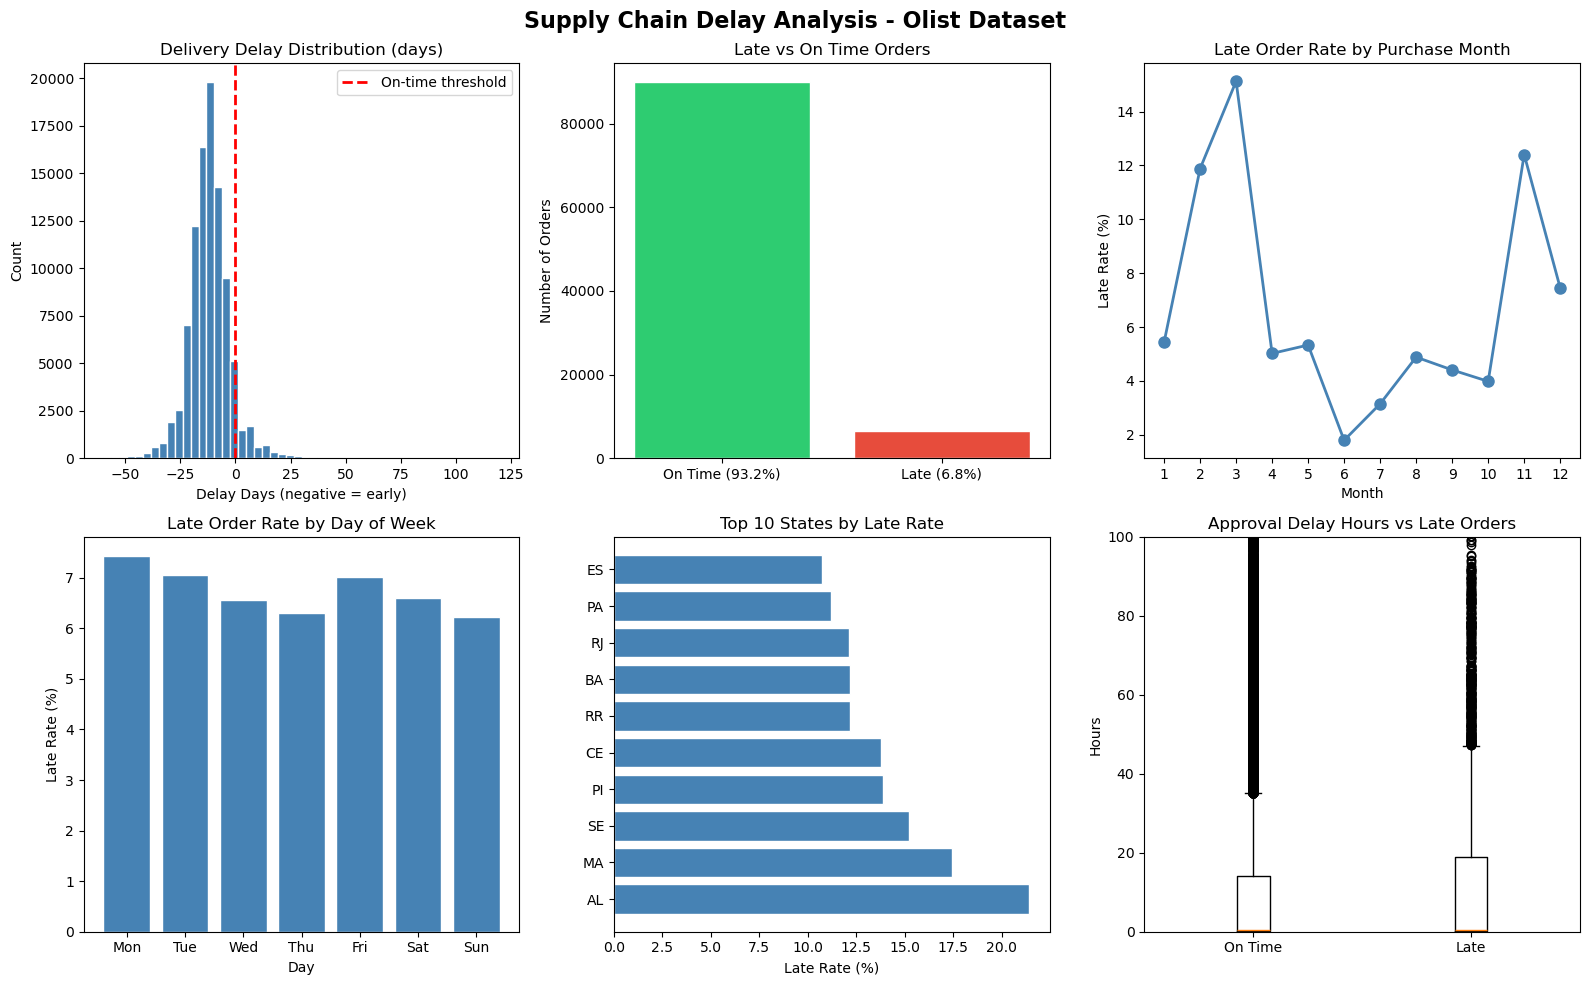

EDA charts saved to dashboard/eda_overview.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Supply Chain Delay Analysis - Olist Dataset', fontsize=16, fontweight='bold')

# Plot 1 - Delay distribution
axes[0,0].hist(orders_full['delay_days'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='On-time threshold')
axes[0,0].set_title('Delivery Delay Distribution (days)')
axes[0,0].set_xlabel('Delay Days (negative = early)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Plot 2 - Late vs On Time
late_counts = orders_full['is_late'].value_counts()
axes[0,1].bar(['On Time (93.2%)', 'Late (6.8%)'], late_counts.values, 
               color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0,1].set_title('Late vs On Time Orders')
axes[0,1].set_ylabel('Number of Orders')

# Plot 3 - Delays by month
monthly_delay = orders_full.groupby('purchase_month')['is_late'].mean() * 100
axes[0,2].plot(monthly_delay.index, monthly_delay.values, 
               marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0,2].set_title('Late Order Rate by Purchase Month')
axes[0,2].set_xlabel('Month')
axes[0,2].set_ylabel('Late Rate (%)')
axes[0,2].set_xticks(range(1,13))

# Plot 4 - Delays by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_delay = orders_full.groupby('purchase_dayofweek')['is_late'].mean() * 100
axes[1,0].bar(day_names, daily_delay.values, color='steelblue', edgecolor='white')
axes[1,0].set_title('Late Order Rate by Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Late Rate (%)')

# Plot 5 - Top 10 states by late rate
state_delay = orders_full.groupby('customer_state')['is_late'].mean().sort_values(ascending=False).head(10) * 100
axes[1,1].barh(state_delay.index, state_delay.values, color='steelblue', edgecolor='white')
axes[1,1].set_title('Top 10 States by Late Rate')
axes[1,1].set_xlabel('Late Rate (%)')

# Plot 6 - Approval delay vs is_late
axes[1,2].boxplot([
    orders_full[orders_full['is_late']==0]['approval_delay_hours'],
    orders_full[orders_full['is_late']==1]['approval_delay_hours']
], labels=['On Time', 'Late'])
axes[1,2].set_title('Approval Delay Hours vs Late Orders')
axes[1,2].set_ylabel('Hours')
axes[1,2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../dashboard/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA charts saved to dashboard/eda_overview.png")

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

# Select features for the model
feature_cols = [
    'num_items',
    'total_price',
    'total_freight',
    'avg_product_weight',
    'avg_product_volume',
    'num_sellers',
    'payment_installments',
    'payment_value',
    'purchase_hour',
    'purchase_dayofweek',
    'purchase_month',
    'purchase_quarter',
    'approval_delay_hours',
    'carrier_delay_hours',
    'estimated_delivery_window',
    'same_state'
]

# Encode payment_type and customer_state
le_payment = LabelEncoder()
le_state = LabelEncoder()

orders_full['payment_type_encoded'] = le_payment.fit_transform(
    orders_full['payment_type'].astype(str)
)
orders_full['customer_state_encoded'] = le_state.fit_transform(
    orders_full['customer_state'].astype(str)
)

feature_cols += ['payment_type_encoded', 'customer_state_encoded']

# Define X and y
X = orders_full[feature_cols]
y = orders_full['is_late']

# Train test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nPositive class ratio: {y_train.mean()*100:.1f}%")

Training set: (77176, 18)
Test set: (19294, 18)

Class distribution in training set:
is_late
0    71949
1     5227
Name: count, dtype: int64

Positive class ratio: 6.8%


In [8]:
# Calculate scale_pos_weight to handle class imbalance
# Formula: count of negative class / count of positive class
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nModel training complete!")

scale_pos_weight: 13.76
[0]	validation_0-auc:0.76884
[50]	validation_0-auc:0.84069
[95]	validation_0-auc:0.84114

Model training complete!


AUC-ROC Score: 0.8434

Classification Report:
              precision    recall  f1-score   support

     On Time       0.97      0.80      0.88     17987
        Late       0.21      0.71      0.32      1307

    accuracy                           0.80     19294
   macro avg       0.59      0.76      0.60     19294
weighted avg       0.92      0.80      0.84     19294



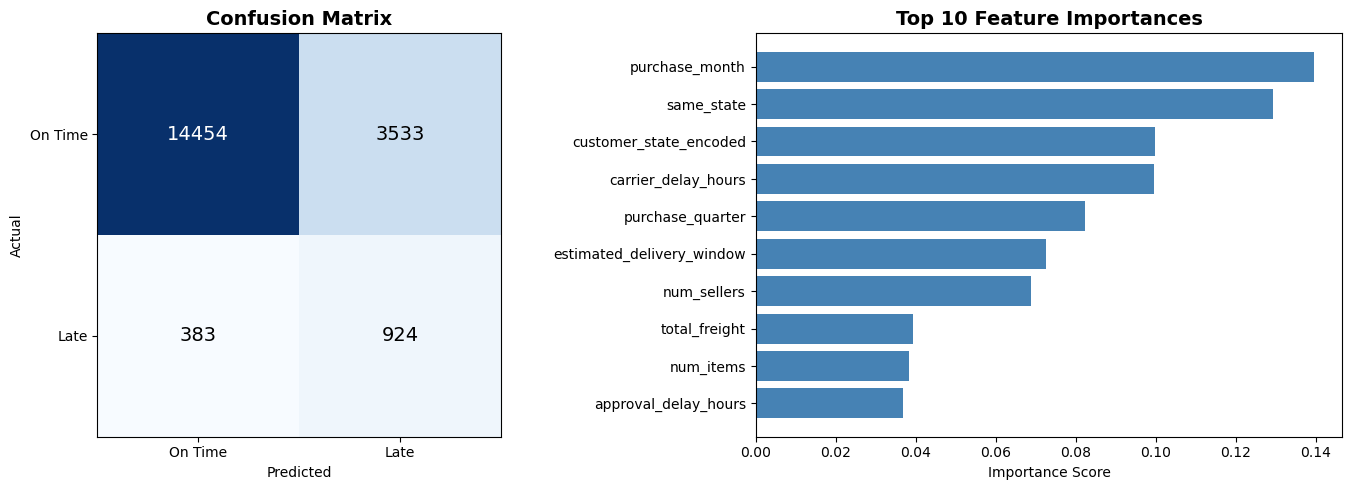


Model evaluation saved to dashboard/model_evaluation.png


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['On Time', 'Late'])
axes[0].set_yticklabels(['On Time', 'Late'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center', 
                    fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')

# Feature importance
feat_importance = pd.Series(
    model.feature_importances_, 
    index=feature_cols
).sort_values(ascending=True).tail(10)

axes[1].barh(feat_importance.index, feat_importance.values, color='steelblue')
axes[1].set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../dashboard/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nModel evaluation saved to dashboard/model_evaluation.png")

In [10]:
import joblib
import os

# Save the model
joblib.dump(model, '../models/xgboost_delay_model.pkl')

# Save the label encoders too — needed for future predictions
joblib.dump(le_payment, '../models/le_payment.pkl')
joblib.dump(le_state, '../models/le_state.pkl')

# Save the feature column list
import json
with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("Saved:")
print("  ✓ models/xgboost_delay_model.pkl")
print("  ✓ models/le_payment.pkl")
print("  ✓ models/le_state.pkl")
print("  ✓ models/feature_cols.json")

# Save the master dataframe for Power BI
orders_full.to_csv('../processed_data/orders_master.csv', index=False)
print("  ✓ processed_data/orders_master.csv")

print(f"\nMaster dataset shape saved: {orders_full.shape}")

Saved:
  ✓ models/xgboost_delay_model.pkl
  ✓ models/le_payment.pkl
  ✓ models/le_state.pkl
  ✓ models/feature_cols.json
  ✓ processed_data/orders_master.csv

Master dataset shape saved: (96470, 35)


In [13]:
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
import os

load_dotenv('../.env')

CONNECTION_STRING = os.getenv("AZURE_CONNECTION_STRING")
CONTAINER_PROCESSED = os.getenv("AZURE_CONTAINER_PROCESSED")

blob_service_client = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_PROCESSED)

# Upload master dataset
files_to_upload = [
    ('../processed_data/orders_master.csv', 'orders_master.csv'),
    ('../dashboard/eda_overview.png', 'eda_overview.png'),
    ('../dashboard/model_evaluation.png', 'model_evaluation.png'),
]

for local_path, blob_name in files_to_upload:
    print(f"Uploading {blob_name}...")
    with open(local_path, 'rb') as data:
        container_client.upload_blob(name=blob_name, data=data, overwrite=True)
    print(f"✓ {blob_name} uploaded")

print("\nAll processed files uploaded to Azure!")
print(f"Container: {CONTAINER_PROCESSED}")

Uploading orders_master.csv...
✓ orders_master.csv uploaded
Uploading eda_overview.png...
✓ eda_overview.png uploaded
Uploading model_evaluation.png...
✓ model_evaluation.png uploaded

All processed files uploaded to Azure!
Container: processed-data


In [12]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "azure-storage-blob", "python-dotenv"])

0

In [14]:
# Seller performance summary for Power BI dashboard
seller_performance = orders_full.groupby('seller_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_review_score=('review_score', 'mean'),
    avg_freight=('total_freight', 'mean'),
    total_revenue=('total_price', 'sum')
).reset_index()

seller_performance['late_rate_pct'] = (seller_performance['late_rate'] * 100).round(2)
seller_performance['avg_delay_days'] = seller_performance['avg_delay_days'].round(2)
seller_performance['avg_review_score'] = seller_performance['avg_review_score'].round(2)
seller_performance = seller_performance.sort_values('late_rate_pct', ascending=False)

# Save locally
seller_performance.to_csv('../processed_data/seller_performance.csv', index=False)
print("Seller performance table:")
print(seller_performance.head(10))
print(f"\nSaved to processed_data/seller_performance.csv")

# Also upload to Azure
with open('../processed_data/seller_performance.csv', 'rb') as data:
    container_client.upload_blob(
        name='seller_performance.csv', 
        data=data, 
        overwrite=True
    )
print("✓ seller_performance.csv uploaded to Azure")

Seller performance table:
   seller_state  total_orders  late_orders  late_rate  avg_delay_days  \
0            AM             3            1   0.333333            9.00   
6            MA           388           74   0.190722          -11.32   
16           RN            51            4   0.078431          -13.55   
21           SP         68415         5015   0.073303          -11.13   
15           RJ          4185          301   0.071924          -12.41   
2            CE            85            6   0.070588          -13.19   
8            MS            47            3   0.063830          -17.23   
4            ES           308           19   0.061688          -13.06   
14           PR          7429          402   0.054112          -14.08   
3            DF           803           42   0.052304          -13.30   

    avg_review_score  avg_freight  total_revenue  late_rate_pct  
0               2.33    27.266667        1177.00          33.33  
6               4.03    31.037706     